In [1]:
from functools import partial

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import optimize
from scipy.ndimage import convolve
from tqdm import tqdm

from spectrumlab.backgrounds.savitzky_golay_background import SavitzkyGolayBackgroundConfig, approximate_savitzky_golay
from spectrumlab.detectors import Detector
from spectrumlab.noises import ConstantNoise
from spectrumlab.peaks.analyte_peaks.shapes import PeakShape
from spectrumlab.peaks.analyte_peaks.shapes.retrieve_shape import retrieve_shape_from_spectrum
from spectrumlab.peaks.blink_peaks import DraftBlinksConfig, draft_blinks
from spectrumlab.picture.colors import COLOR
from spectrumlab.spectra import EmittedSpectrum
from spectrumlab.types import Array, Number, R

from spectrumlab_emulations.apertures import Aperture, RectangularApertureShape
from spectrumlab_emulations.apparatus import Apparatus, VoigtApparatusShape
from spectrumlab_emulations.experiments.spectra_emulation import RandomPeakExperiment, RandomPeakExperimentConfig

from plugin.managers.process_manager.filters.scale_filter import estimate_alpha

In [18]:
N_NUMBERS = 2048
N_FRAMES = 10
N_ITERS = 100

EXPOSURE = 100

SHAPE = VoigtApparatusShape(
    width=28,
    asymmetry=+0.1,
    ratio=0.1,
)

MU = -1
SIGMA = .5

ALPHA = 0.02


verbose = True
show = True

In [19]:
def transformer(
    intensity: Array[R],
    background: Array[R],
    alpha: float = 0,
) -> Array[R]:
    assert len(intensity) == len(background)

    number = np.arange(len(intensity))
    index_even = number % 2 == 0
    index_odd = number % 2 == 1

    value = intensity.copy() + background.copy()
    value[index_even] = value[index_even] * (1 - alpha/2)
    value[index_odd] = value[index_odd] * (1 + alpha/2)
    return value


In [20]:
detector = Detector.BLPP2000

experiment = RandomPeakExperiment(
    config=RandomPeakExperimentConfig(
        n_numbers=N_NUMBERS,
        n_frames=N_FRAMES,

        detector=detector,
        apparatus=Apparatus(
            detector=detector,
            shape=SHAPE,
        ),
        aperture=Aperture(
            detector=detector,
            shape=RectangularApertureShape(),
        ),

        exposure=EXPOSURE,
        position=np.random.uniform(0, N_NUMBERS, size=(N_ITERS,)),
        intensity=10**np.random.normal(MU, SIGMA, size=(N_ITERS,)),
    ),
)
experiment = experiment.setup(
    # seed=42,
)

In [21]:
scalar = 1
number = np.arange(N_NUMBERS)


background = np.zeros(N_NUMBERS, dtype=float) + .42
for amplitude, mu, sigma in [
    (10, 2500, 75),
    (6, 600, 125),
    (4, 1400, 75),
    (3, 1700, 200),
]:
    line = amplitude * np.exp(-((number - mu)**2) / (2 * sigma**2))
    background += line


In [22]:
unicorn = experiment.run(
    is_noised=False,
    transformer=partial(transformer, background=background),
)
spectrum = experiment.run(
    is_noised=True,
    transformer=partial(transformer, alpha=ALPHA, background=background),
)


peaks: 144


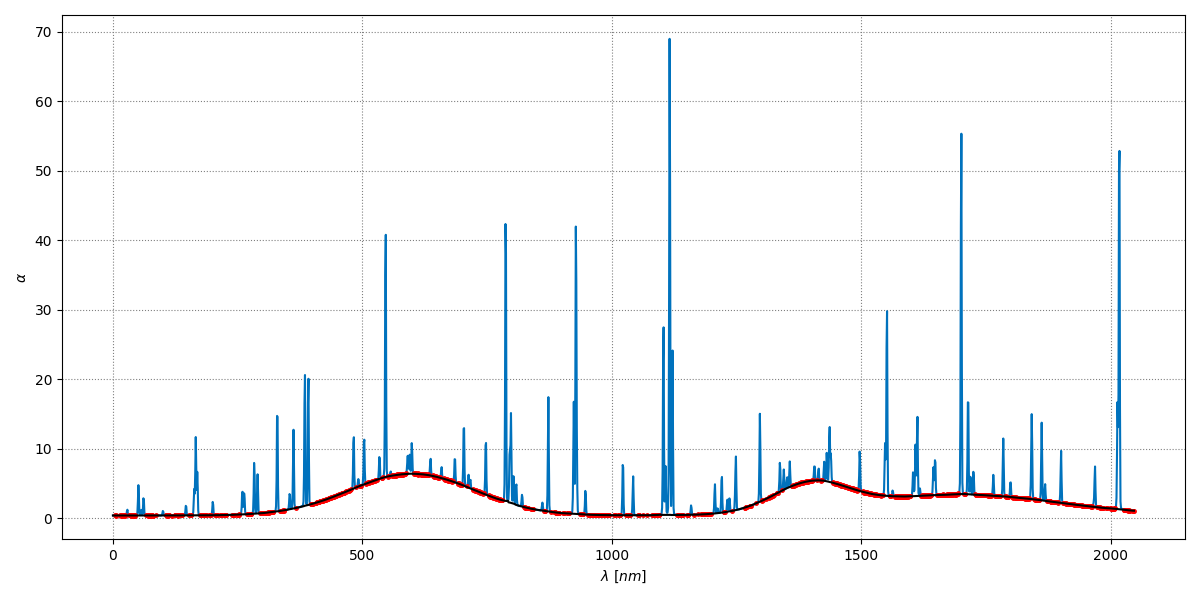

In [23]:
%matplotlib widget

peaks = draft_blinks(
    spectrum=EmittedSpectrum(
        # intensity=convolve(spectrum.intensity, [.25, .5, .25], mode='mirror'),
        intensity=spectrum.intensity,
    ),
    config=DraftBlinksConfig(
        n_counts_min=4,
        except_clipped_peak=False,
        except_sloped_peak=False,
        # except_edges=True,
        amplitude_min=.01,
    ),
)
print('peaks: {}'.format(len(peaks)))


mask = np.full(spectrum.n_numbers, True)
for peak in peaks:
    lb, ub = peak.minima
    mask[lb:ub+1] = False


if show:
    fig, ax = plt.subplots(figsize=(12, 6), tight_layout=True)

    ax.plot(
        spectrum.wavelength,
        spectrum.intensity,
        color=COLOR['blue'], alpha=1,
    )
    ax.plot(
        spectrum.wavelength[mask],
        spectrum.intensity[mask],
        linestyle='none', color='red', alpha=1,
        marker='.', markersize=5,
    )
    ax.plot(
        spectrum.wavelength,
        approximate_savitzky_golay(
            intensity=spectrum.intensity,
            mask=~mask,
            config=SavitzkyGolayBackgroundConfig(
                window=64,
                degree=2,
                n_counts_min=16,
                window_max=1024,
            ),
        ),
        color='black', alpha=1,
    )

    # ax.set_ylim([-0.5, +2.5])

    ax.set_xlabel(r'$\lambda$ [$nm$]')
    ax.set_ylabel(r'$\alpha$')
    ax.grid(color='grey', linestyle=':')

    plt.show()

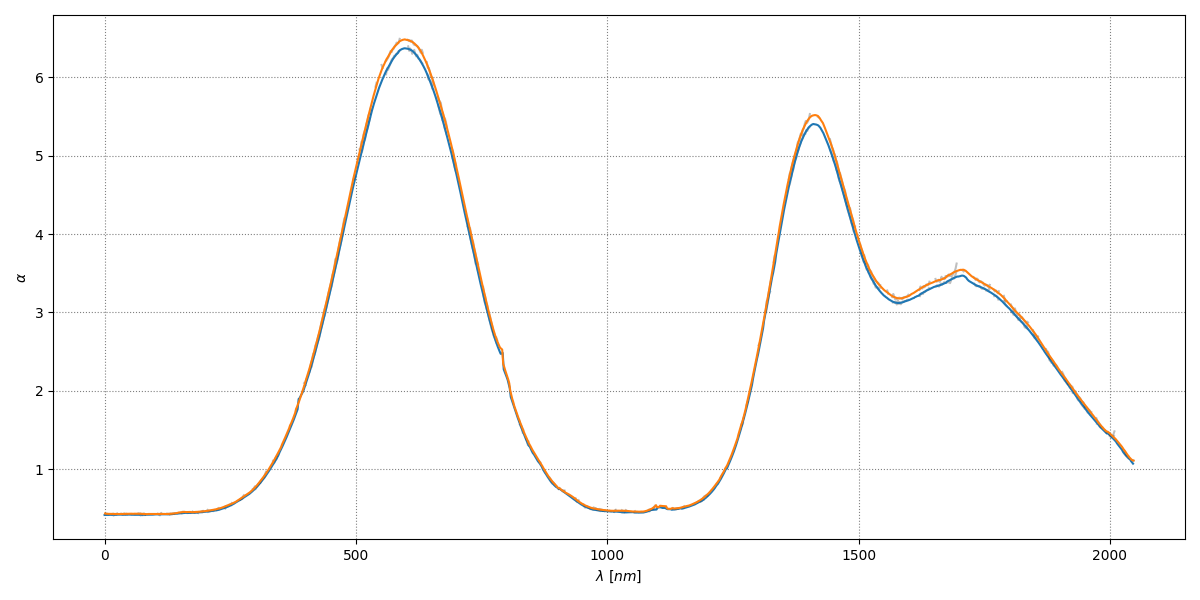

In [24]:
config = SavitzkyGolayBackgroundConfig(
    window=32,
    degree=2,
    n_counts_min=8,
    window_max=512,
)

#
index_even = spectrum.number % 2 == 0
temp = spectrum.intensity[index_even]
temp[~mask[index_even]] = np.nan
intensity_even = spectrum.intensity[index_even]
intensity_even[~mask[index_even]] = np.nan
intensity_filled_even = approximate_savitzky_golay(
    intensity=temp,
    mask=~mask[index_even],
    config=config,
)

#
index_odd = spectrum.number % 2 == 1
temp = spectrum.intensity[index_odd]
temp[~mask[index_odd]] = np.nan
intensity_odd = spectrum.intensity[index_odd]
intensity_odd[~mask[index_odd]] = np.nan
intensity_filled_odd = approximate_savitzky_golay(
    intensity=temp,
    mask=~mask[index_odd],
    config=config,
)

# show
if show:
    fig, ax = plt.subplots(figsize=(12, 6), tight_layout=True)

    ax.plot(
        number[index_even], intensity_even,
        color='black', alpha=.25,
    )
    ax.plot(number[index_even], intensity_filled_even)
    ax.plot(
        number[index_odd], intensity_odd,
        color='black', alpha=.25,
    )
    ax.plot(number[index_odd], intensity_filled_odd)

    ax.set_xlabel(r'$\lambda$ [$nm$]')
    ax.set_ylabel(r'$\alpha$')
    ax.grid(color='grey', linestyle=':')

    plt.show()

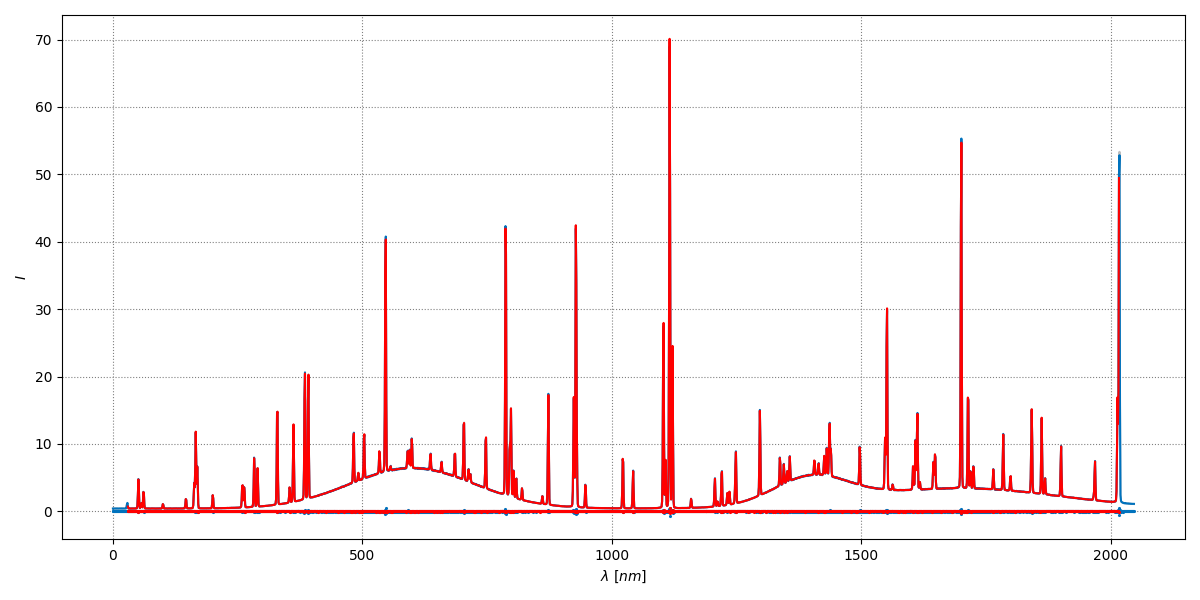

In [25]:
%matplotlib widget

intensity_filled = spectrum.intensity.copy()
intensity_filled[index_even] = intensity_filled_even
intensity_filled[index_odd] = intensity_filled_odd
intensity_filled_smooth = convolve(intensity_filled, [.25, .5, .25], mode='mirror')

alpha_hat = intensity_filled / intensity_filled_smooth
alpha_hat_smooth = np.full(spectrum.n_numbers, 0.)
for index in [index_even, index_odd]:
    alpha_hat_smooth[index] = approximate_savitzky_golay(
        intensity=alpha_hat[index],
        mask=np.full(spectrum.n_numbers//2, False),
        config= SavitzkyGolayBackgroundConfig(
            window=32,
            degree=1,
        ),
    )

if show:
    fig, ax = plt.subplots(figsize=(12, 6), tight_layout=True)

    ax.plot(
        unicorn.wavelength,
        unicorn.intensity,
        color='black', alpha=.25,
    )
    ax.plot(
        spectrum.wavelength,
        spectrum.intensity,
        color=COLOR['blue'], alpha=1,
    )
    # ax.plot(
    #     spectrum.wavelength[mask],
    #     spectrum.intensity[mask],
    #     linestyle='none', color=COLOR['blue'], alpha=1,
    #     marker='.', markersize=5,
    #     label='$s_{k}$',
    # )
    ax.plot(
        spectrum.wavelength,
        spectrum.intensity / alpha_hat_smooth,
        color='red', alpha=1,
    )

    ax.plot(
        spectrum.wavelength,
        spectrum.intensity - unicorn.intensity,
        linestyle='none', color=COLOR['blue'], alpha=1,
        marker='.', markersize=2.5,
    )
    ax.plot(
        spectrum.wavelength,
        spectrum.intensity / alpha_hat_smooth - unicorn.intensity,
        linestyle='none', color='red', alpha=1,
        marker='.', markersize=2.5,
    )

    ax.set_xlabel(r'$\lambda$ [$nm$]')
    ax.set_ylabel(r'$I$')
    ax.grid(color='grey', linestyle=':')

    plt.show()